In [2]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict


In [23]:
class FinancialState(TypedDict):
    employee_name : str
    salary : float
    hours :  float
    rating : float
    gross_pay : float
    net_pay : float
    final_summary :str


In [24]:
def validate_data(state : FinancialState) -> FinancialState:
    salary  = state['salary']
    hours = state['hours']
    
    if not isinstance(salary , ( int  , float)) or not isinstance(hours , ( int , float)):
        raise ValueError("Salary and hours must be numeric values")
    if salary < 0 or hours < 0:
        raise ValueError("Salary and hours must be non-negative")
    
    return state
    

def calculate_gross_pay(state : FinancialState):
    salary  = state['salary']
    hours = state['hours']
    if hours > 40:
        overtime = hours - 40
        gross_pay = (salary*40) + (salary * 1.5 * overtime)
    gross_pay = salary * hours
    return {"gross_pay" : gross_pay}

def apply_tax(state : FinancialState):
    gross_pay  = state['gross_pay']
    
    if gross_pay < 5000:
        tax_rate = 0.10
    else:
        tax_rate = 0.20
    
    net_pay = gross_pay - (gross_pay * tax_rate)
    state['net_pay'] = net_pay

    return {"net_pay" : net_pay}

def add_bonus(state :  FinancialState):
    rating = state['rating']
    net_pay = state['net_pay']
    
    bonus = 1000 if rating > 5 else 500
    state['net_pay'] += bonus
    
    return {"net_pay" : net_pay}

def generate_summary(state: FinancialState):
    state["final_summary"] = (
        f"name - {state['employee_name']}"
        f"Final Take-Home Pay: {state['net_pay']:.2f} "
        f"(Gross: {state['gross_pay']:.2f}, Rating: {state['rating']})"
    )
    return {"final_summary" : state['final_summary']}


In [25]:
graph = StateGraph(FinancialState)

graph.add_node("validate" , validate_data)
graph.add_node("gross_calc" , calculate_gross_pay)
graph.add_node("tax" , apply_tax)
graph.add_node("bonus" , add_bonus)
graph.add_node("summary" , generate_summary)

graph.add_edge(START , "validate")
graph.add_edge("validate" , "gross_calc")
graph.add_edge("gross_calc" , "tax")
graph.add_edge("tax" , "bonus")
graph.add_edge("bonus" , "summary")
graph.add_edge("summary" , END)

workflow = graph.compile()


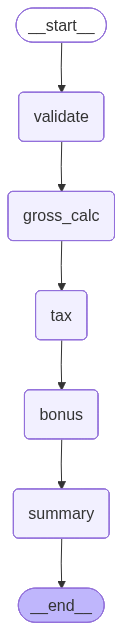

In [26]:
workflow


In [30]:
intial_state = {
    "employee_name" : "Ph. Kumar",
    "salary" : 1001,
    "hours" : 46,
    "rating" : 5.5
}
final_state = workflow.invoke(intial_state)


In [31]:
final_state


{'employee_name': 'Ph. Kumar',
 'salary': 1001,
 'hours': 46,
 'rating': 5.5,
 'gross_pay': 46046,
 'net_pay': 36836.8,
 'final_summary': 'name - Ph. KumarFinal Take-Home Pay: 36836.80 (Gross: 46046.00, Rating: 5.5)'}

In [32]:
final_state["employee_name"]


'Ph. Kumar'